In [8]:
from azure.identity import DefaultAzureCredential
from azure.keyvault.secrets import SecretClient

VAULT_URL = "https://spectral-nature-kvault.vault.azure.net/"  # your Key Vault URL

credential = DefaultAzureCredential()
client = SecretClient(vault_url=VAULT_URL, credential=credential)

secret = client.get_secret("Key")
#print("Key:", secret.value)

secret = client.get_secret("Secret")
#print("Secret:", secret.value)

In [2]:
def get_historical_bars(symbol, start, end, timeframe='1Day'):
    """Retrieves historical bar data from Alpaca."""
    return api.get_bars(symbol, timeframe, start=start, end=end)

def get_latest_quote(symbol):
    """Retrieves the latest quote for a given symbol from Alpaca."""
    return api.get_latest_quote(symbol)

def get_snapshot(symbol):
    """Retrieves the current snapshot (latest trade/quote) for a given symbol."""
    return api.get_snapshot(symbol)

def get_options_data(symbol):
    """Placeholder for options data retrieval—depends on Alpaca’s available endpoints."""
    # Alpaca may not support direct options data retrieval via the same REST API.
    # Check Alpaca documentation or alternate data provider for options data.
    pass


In [6]:
%pip install alpaca_trade_api

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.8/106.8 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.7/323.7 kB 12.2 MB/s eta 0:00:00
  Attempting uninstall: msgpack
    Found existing installation: msgpack 1.0.8
    Uninstalling msgpack-1.0.8:
      Successfully uninstalled msgpack-1.0.8
  Attempting uninstall: websockets
    Found existing installation: websockets 13.1
    Uninstalling websockets-13.1:
      Successfully uninstalled websockets-13.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-sql 2024.5.0 requires dask[dataframe]>=2024.4.1, but you have dask 2023.2.0 which is incompatible.
dask-sql 2024.5.0 requires distributed>=2024.4.1, but you have distributed 2023.2.0 which is incompatible.
dask-sql 2024.5.0 requires pandas>=1.4.0, but you have pandas 1.3.5 which is incompatible.
Note: you may need to restart the ker

In [12]:
secret.Key

AttributeError: 'KeyVaultSecret' object has no attribute 'Key'

In [13]:
from alpaca_trade_api.rest import REST

# Example usage of the functions
symbol = "AAPL"  # Replace with your desired symbol
start_date = "2023-01-01"
end_date = "2023-10-01"

# Define and authenticate the `api` object

API_KEY = client.get_secret("Key").value  # Replace with your Alpaca API key
API_SECRET = client.get_secret("Secret").value # Replace with your Alpaca API secret
BASE_URL = "https://paper-api.alpaca.markets"  # Replace with your Alpaca base URL if needed

api = REST(API_KEY, API_SECRET, BASE_URL)
try:
    # Retrieve historical bars
    historical_bars = get_historical_bars(symbol, start_date, end_date)
    print("Historical Bars:")
    print(historical_bars)

    # Retrieve the latest quote
    latest_quote = get_latest_quote(symbol)
    print("\nLatest Quote:")
    print(latest_quote)

    # Retrieve the snapshot
    snapshot = get_snapshot(symbol)
    print("\nSnapshot:")
    print(snapshot)
except NameError:
    print("Ensure the `api` object is defined and authenticated before running these functions.")

Historical Bars:
[Bar({   'c': 125.07,
    'h': 130.9,
    'l': 124.17,
    'n': 1021067,
    'o': 130.28,
    't': '2023-01-03T05:00:00Z',
    'v': 124289279,
    'vw': 125.660032}), Bar({   'c': 126.36,
    'h': 128.6557,
    'l': 125.08,
    'n': 770045,
    'o': 126.89,
    't': '2023-01-04T05:00:00Z',
    'v': 95426133,
    'vw': 126.643011}), Bar({   'c': 125.02,
    'h': 127.77,
    'l': 124.76,
    'n': 665463,
    'o': 127.13,
    't': '2023-01-05T05:00:00Z',
    'v': 88344592,
    'vw': 126.006961}), Bar({   'c': 129.62,
    'h': 130.29,
    'l': 124.89,
    'n': 709888,
    'o': 126.01,
    't': '2023-01-06T05:00:00Z',
    'v': 96468673,
    'vw': 128.362627}), Bar({   'c': 130.15,
    'h': 133.41,
    'l': 129.89,
    'n': 645367,
    'o': 130.465,
    't': '2023-01-09T05:00:00Z',
    'v': 76653608,
    'vw': 131.545593}), Bar({   'c': 130.73,
    'h': 131.2636,
    'l': 128.12,
    'n': 554942,
    'o': 130.26,
    't': '2023-01-10T05:00:00Z',
    'v': 68415086,
    'vw': 

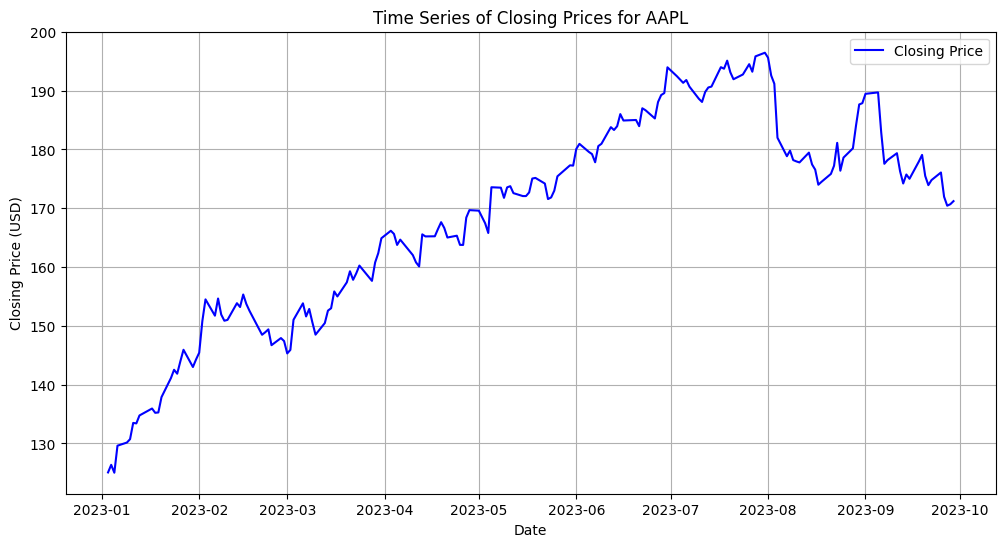

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert historical_bars to a DataFrame
data = {
    "timestamp": [bar.t for bar in historical_bars],
    "close": [bar.c for bar in historical_bars]
}
df = pd.DataFrame(data)

# Ensure the timestamp is in datetime format
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Plot the time series of closing prices
plt.figure(figsize=(12, 6))
plt.plot(df['timestamp'], df['close'], label='Closing Price', color='blue')
plt.title(f"Time Series of Closing Prices for {symbol}")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.legend()
plt.grid()
plt.show()
